# Data Preprocessing and Exploratory Analysis of Functional Capacity and Quality of Life in Pediatric Patients with Marfan Syndrome
by Chloé Laignel-Granier

## Installation of required Python packages

In [1]:
import sys
import subprocess

packages = ["pandas", "numpy", "matplotlib", "seaborn"]

for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

## Step 1: Import of the raw dataset

In [2]:
# Load dataset
import pandas as pd
import numpy as np
file_path = "data/Marfan.xlsx"
data = pd.read_excel(file_path)

# Total number of patients
print(f"The dataset includes {len(data)} patients.")


The dataset includes 28 patients.


## Step 2 : Clean data

In [3]:
# Rename variables and retain VAT (ventilatory threshold) for descriptive analysis of included and excluded patients
data = data.rename(columns={
    "VO2_SV1__percent_theoretical_after": "VAT_after",
    "VO2_SV1__percent_theoretical_before": "VAT_before"
})
# Standardize variable names
data.columns = data.columns.str.lower().str.strip()
data.head()

,id,age,sexe,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,...,pedsql_emotionself_before,pedsql_emotionself_after,pedsql_relationself_before,pedsql_relationself_after,pedsql_ecoleself_before,pedsql_ecoleself_after,pedsql_psycosocialself_before,pedsql_psycosocialself_after,pedsql_physiqueself_before,pedsql_physiqueself_after
0,1,10.529774,M,47.8,162.6,18.079517,660,737.0,29.918262,39.958707,...,60,70.0,65,85.0,75,75.0,66.666667,76.666667,75.000,71.875
1,2,14.351814,F,43.0,174.0,14.202669,598,NaN,38.742243,NaN,...,80,NaN,85,NaN,95,NaN,86.666667,NaN,87.500,NaN
2,3,10.704997,M,26.0,142.0,12.894267,556,618.0,38.237739,41.531482,...,85,85.0,100,100.0,85,85.0,90.000000,90.000000,96.875,96.875
3,4,17.393566,F,69.0,185.5,20.052165,588,692.0,28.950695,45.052754,...,50,55.0,50,55.0,65,70.0,55.000000,60.000000,46.875,53.125
4,5,18.986995,F,54.8,177.0,17.491781,583,NaN,39.959155,NaN,...,75,65.0,75,75.0,100,100.0,83.333333,80.000000,62.500,53.125


Variable names were standardized by converting all column names to lowercase and removing leading and trailing spaces to ensure consistency and prevent errors during data processing.

In [4]:
# Data quality checks

from IPython.display import display, Markdown

display(Markdown("### Missing Data"))
missing_table = data.isna().sum().to_frame(name="Missing values")
display(missing_table)

display(Markdown("### Duplicate Observations"))
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

display(Markdown("### Descriptive Statistics"))
display(data.describe().round(1))

### Missing Data

,Missing values
id,0
age,0
sexe,0
weight_kg,0
height_cm,0
bmi_kg_cm2,0
6minwt_distance_traveled_m_before,0
6minwt_distance_traveled_m_after,8
vat_before,0
vat_after,8


### Duplicate Observations

Number of duplicate rows: 0


### Descriptive Statistics

,id,age,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,...,pedsql_emotionself_before,pedsql_emotionself_after,pedsql_relationself_before,pedsql_relationself_after,pedsql_ecoleself_before,pedsql_ecoleself_after,pedsql_psycosocialself_before,pedsql_psycosocialself_after,pedsql_physiqueself_before,pedsql_physiqueself_after
count,28.0,28.0,28.0,28.0,28.0,28.0,20.0,28.0,20.0,28.0,...,28.0,22.0,28.0,22.0,28.0,22.0,28.0,22.0,28.0,22.0
mean,14.5,12.8,46.9,166.1,16.4,583.1,619.2,34.6,42.8,71.7,...,69.6,76.8,71.8,83.9,71.6,74.3,71.0,78.3,73.1,80.0
std,8.2,3.7,16.8,19.5,3.4,49.0,79.9,8.5,9.7,15.1,...,16.8,15.9,21.3,12.6,19.2,15.9,16.0,11.8,16.8,15.5
min,1.0,7.2,22.0,134.0,12.1,450.0,460.0,18.4,25.2,34.8,...,35.0,40.0,20.0,55.0,25.0,40.0,33.3,56.7,37.5,53.1
25%,7.8,10.3,31.2,149.2,13.6,559.0,582.5,29.0,38.7,64.7,...,60.0,66.2,60.0,76.2,60.0,62.5,63.3,72.1,60.9,66.4
50%,14.5,12.5,48.4,167.5,15.0,588.0,610.0,33.8,42.1,69.6,...,70.0,77.5,75.0,80.0,75.0,77.5,72.5,79.2,73.4,82.8
75%,21.2,15.5,59.4,182.2,18.9,621.2,684.5,38.9,47.8,84.0,...,80.0,90.0,90.0,97.5,86.2,85.0,83.3,86.7,87.5,93.0
max,28.0,19.9,82.0,199.0,24.5,660.0,744.0,56.5,63.1,93.5,...,100.0,100.0,100.0,100.0,100.0,100.0,91.7,98.3,96.9,100.0


Data quality was assessed by examining missing values, duplicate observations, and descriptive statistics. Missing data were quantified for each variable, duplicate entries were checked, and summary statistics were used to identify potential outliers and inconsistencies.

## Step 3 : Separate the analyzed and excluded patients

In [5]:
# Define key variables for analysis
cols_all = [
    "6minwt_distance_traveled_m_before",
    "6minwt_distance_traveled_m_after",
    "pedsql_totalself_after",
    "pedsql_santeself_after",
    "pedsql_relationself_after",
    "pedsql_ecoleself_after",
    "pedsql_psycosocialself_after",  
    "pedsql_physiqueself_after"
]

# Analysable patients (no missing data)
data_included = data.dropna(subset=cols_all)

# Excluded patients
data_excluded = data[data[cols_all].isna().any(axis=1)]

# Verification
print("Total patients:", len(data))
print("Included:", len(data_included))
print("Excluded:", len(data_excluded))

Total patients: 28
Included: 20
Excluded: 8


Key outcome measures included the 6-minute walk test (6MWT) and PedsQL quality of life scores.

Patients with missing data for these variables at baseline or post-intervention were excluded from the primary analysis.

## Step 4 : Transformation to Long Format

In [6]:
# Transform the data to long format for distance traveled
distance_long = pd.melt(
    data_included,
    id_vars=["id"],
    value_vars=["6minwt_distance_traveled_m_before","6minwt_distance_traveled_m_after"],
    var_name="time",
    value_name="distance"
)

# Simplify the time variable
distance_long["time"] = distance_long["time"].map({
     "6minwt_distance_traveled_m_before": "T-3",
     "6minwt_distance_traveled_m_after": "T+6"
 })
print(distance_long)

    id time  distance
0    1  T-3     660.0
1    3  T-3     556.0
2    4  T-3     588.0
3    6  T-3     635.0
4    8  T-3     640.0
5    9  T-3     593.0
6   10  T-3     551.0
7   11  T-3     516.0
8   13  T-3     625.0
9   14  T-3     526.0
10  15  T-3     608.0
11  18  T-3     620.0
12  19  T-3     495.0
13  20  T-3     650.0
14  21  T-3     580.0
15  22  T-3     560.0
16  23  T-3     450.0
17  24  T-3     560.0
18  26  T-3     535.0
19  28  T-3     600.0
20   1  T+6     737.0
21   3  T+6     618.0
22   4  T+6     692.0
23   6  T+6     697.0
24   8  T+6     598.0
25   9  T+6     682.0
26  10  T+6     744.0
27  11  T+6     682.0
28  13  T+6     575.0
29  14  T+6     585.0
30  15  T+6     605.0
31  18  T+6     615.0
32  19  T+6     490.0
33  20  T+6     725.0
34  21  T+6     540.0
35  22  T+6     625.0
36  23  T+6     460.0
37  24  T+6     530.0
38  26  T+6     590.0
39  28  T+6     595.0


Data were converted to long format for visualization and paired analysis.

## Step 5: Export data_clean and data_excluded to R

In [7]:
# Export data for further analysis
data_included.to_excel("data/data_clean.xlsx", index=False)
data_excluded.to_excel("data/data_excluded.xlsx", index=False)

## Step 6: Analysis of 6MWT — Calculation of Changes and Data Visualization

### Calculation of change (6MWT)

In [8]:
# Individual changes in 6MWT distance were calculated as the difference between post- and pre-intervention values.

data_included["delta_6mwt"] = data_included["6minwt_distance_traveled_m_after"] - data_included["6minwt_distance_traveled_m_before"]
print(data_included[["id", "delta_6mwt"]])

    id  delta_6mwt
0    1        77.0
2    3        62.0
3    4       104.0
5    6        62.0
7    8       -42.0
8    9        89.0
9   10       193.0
10  11       166.0
12  13       -50.0
13  14        59.0
14  15        -3.0
17  18        -5.0
18  19        -5.0
19  20        75.0
20  21       -40.0
21  22        65.0
22  23        10.0
23  24       -30.0
25  26        55.0
27  28        -5.0


### Data visualization

#### Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention

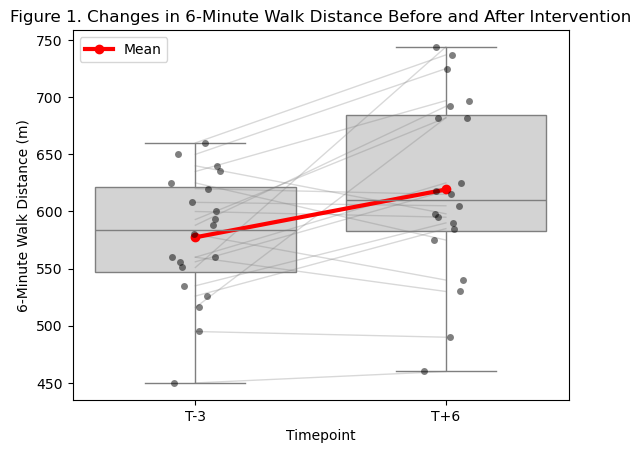

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot showing the distribution at each timepoint
sns.boxplot(
    data=distance_long,
    x="time",
    y="distance",
    color="lightgrey"
)

# Individual data points
sns.stripplot(
    data=distance_long,
    x="time",
    y="distance",
    color="black",
    alpha=0.5,
    jitter=True
)

# Paired lines for each patient (before → after)
for i in range(len(data_included)):
    plt.plot(
        ["T-3", "T+6"],
        [
            data_included["6minwt_distance_traveled_m_before"].iloc[i],
            data_included["6minwt_distance_traveled_m_after"].iloc[i]
        ],
        color="grey",
        alpha=0.3,
        linewidth=1
    )

# Compute mean values at each timepoint
mean_before = data_included["6minwt_distance_traveled_m_before"].mean()
mean_after = data_included["6minwt_distance_traveled_m_after"].mean()

# Add mean line (highlighted)
plt.plot(
    ["T-3", "T+6"],
    [mean_before, mean_after],
    color="red",
    linewidth=3,
    marker="o",
    label="Mean"
)

# Labels and title
plt.xlabel("Timepoint")
plt.ylabel("6-Minute Walk Distance (m)")
plt.title("Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_1_Changes_in_6MWT_Before_After.png",
    bbox_inches="tight"
)

# Display the plot
plt.show()

Data were visualized using boxplots with individual paired lines to illustrate changes in 6-minute walk distance between baseline (T−3) and post-intervention (T+6).

The results show an overall increase in walking distance at T+6, suggesting an improvement in functional capacity. Most individual trajectories follow an upward trend, although some variability remains between patients.

Overall, this figure provides a preliminary visual indication of improvement, which will be further assessed by statistical analysis.

####  Figure 2. Distribution of Changes in 6-Minute Walk Distance

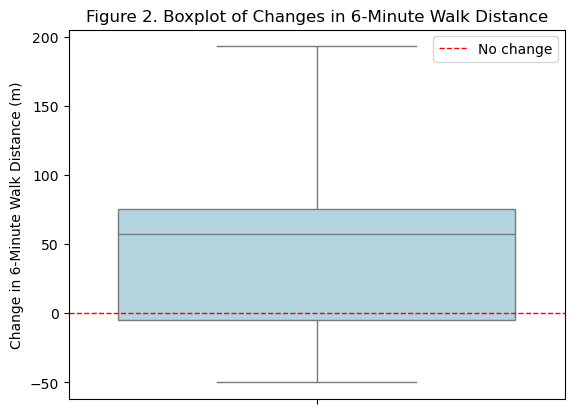

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot showing the distribution of individual changes (delta)
sns.boxplot(
    y=data_included["delta_6mwt"],
    color="lightblue"
)

# Add reference line at zero (no change)
plt.axhline(
    0,
    linestyle="--",
    color="red",
    linewidth=1,
    label="No change"
)

# Labels and title
plt.ylabel("Change in 6-Minute Walk Distance (m)")
plt.title("Figure 2. Boxplot of Changes in 6-Minute Walk Distance")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_2_Boxplot_of_Changes_in_6MWT.png",
    bbox_inches="tight"
)

# Display the plot
plt.show()

#### Figure_3_Histogram_of_Individual_Changes_in_the_6-Minute_Walk_Test

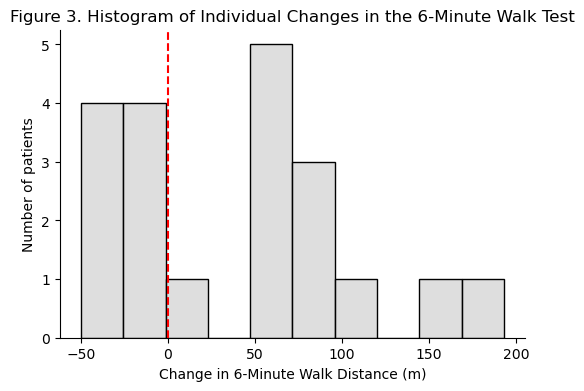

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output folder if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Plot
plt.figure(figsize=(6, 4))

sns.histplot(data=data_included, x="delta_6mwt", bins=10, color="lightgrey", edgecolor="black")

# Vertical line at 0
plt.axvline(x=0, linestyle="--", color="red")

# Labels and title
plt.xlabel("Change in 6-Minute Walk Distance (m)")
plt.ylabel("Number of patients")
plt.title("Figure 3. Histogram of Individual Changes in the 6-Minute Walk Test")

# Minimal theme
sns.despine()

# Save as PDF
plt.savefig("figures/Figure_3_Histogram_of_Individual_Changes_in_the_6MWT.png", bbox_inches="tight")

# Show plot
plt.show()

The distribution of individual changes in 6-minute walk distance (Δ6MWT) was explored using a boxplot (Figure 2) and a histogram (Figure 3) prior to statistical analysis.

Both visualizations indicate that the majority of patients experienced an improvement, as reflected by a median above zero and a predominance of positive values. However, some variability is observed, with a few patients showing no improvement or a decrease in performance.

The histogram further suggests a right-skewed distribution, indicating that some patients achieved larger improvements.

Overall, these exploratory analyses support the use of a non-parametric statistical approach.

#### Table 1. Distribution and changes in 6-minute walk distance

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt

# Format median[IQR]
summary_table = distance_long.groupby("time")["distance"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Create formatted column
summary_table["Median [IQR]"] = (
    summary_table["Median"].round(1).astype(str) + " [" +
    summary_table["Q1"].round(1).astype(str) + "–" +
    summary_table["Q3"].round(1).astype(str) + "]"
)

# Keep only useful column
summary_table = summary_table[["Median [IQR]"]]

# Rename index
summary_table.index = ["T-3", "T+6"]

# delta median[IQR]
delta_median = data_included["delta_6mwt"].median()
delta_q1 = data_included["delta_6mwt"].quantile(0.25)
delta_q3 = data_included["delta_6mwt"].quantile(0.75)

delta_summary = pd.DataFrame({
    "Median [IQR]": [
        f"{round(delta_median,1)} [{round(delta_q1,1)}–{round(delta_q3,1)}]"
    ]
}, index=["Δ (T+6 – T-3)"])

# Delta summary 
improvement = (data_included["delta_6mwt"] > 0).sum()
no_change = (data_included["delta_6mwt"] == 0).sum()
decrease = (data_included["delta_6mwt"] < 0).sum()

total = len(data_included)
delta_table = pd.DataFrame({
    "Change (n, %)": [
        f"{improvement} ({round(improvement/total*100,1)}%)",
        f"{no_change} ({round(no_change/total*100,1)}%)",
        f"{decrease} ({round(decrease/total*100,1)}%)"
    ]
}, index=["Improved", "No change", "Decreased"])


# Final table
final_table = pd.concat([summary_table, delta_summary, delta_table])


# Export PDF
fig, ax = plt.subplots(figsize=(6,4))
ax.axis('off')

table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    rowLabels=final_table.index,
    loc='center'
)

# Title
plt.title(
    "Table 1. Distribution and changes in 6-minute walk distance",
    fontsize=12,
    pad=20
)

plt.savefig("figures/Table_1_Distribution_and_changes_in_6MWT.png", bbox_inches="tight")
plt.close()

from IPython.display import display

display(final_table.style.set_caption(
    "Table 1. Distribution and changes in 6-minute walk distance"
))

,Median [IQR],"Change (n, %)"
T-3,610.0 [582.5–684.5],nan
T+6,584.0 [547.0–621.2],nan
Δ (T+6 – T-3),57.0 [-5.0–75.5],nan
Improved,nan,12 (60.0%)
No change,nan,0 (0.0%)
Decreased,nan,8 (40.0%)


Descriptive statistics are reported as median [interquartile range].

Although the median 6-minute walk distance slightly decreased between baseline and post-intervention, the median individual change was positive (+57.0 m), suggesting an overall improvement with inter-individual variability.

Overall, 60% of patients improved, while 40% showed a decrease.

Exploratory analysis suggests a general trend toward improvement in functional capacity after the intervention. This observation will be further examined using statistical tests.